## Mountain car MDP
#### solving the mountain car MDP in the gymnasium library using Q-learning. 
#### It involves a car trying to climb up a sinosudal hill, we'll explore the inbuilt gym env and later find an optimal policy

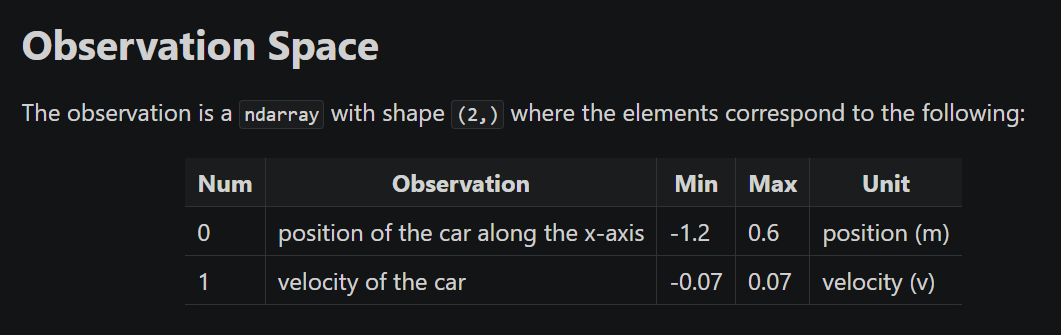
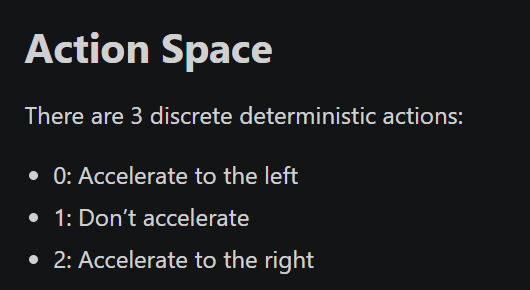
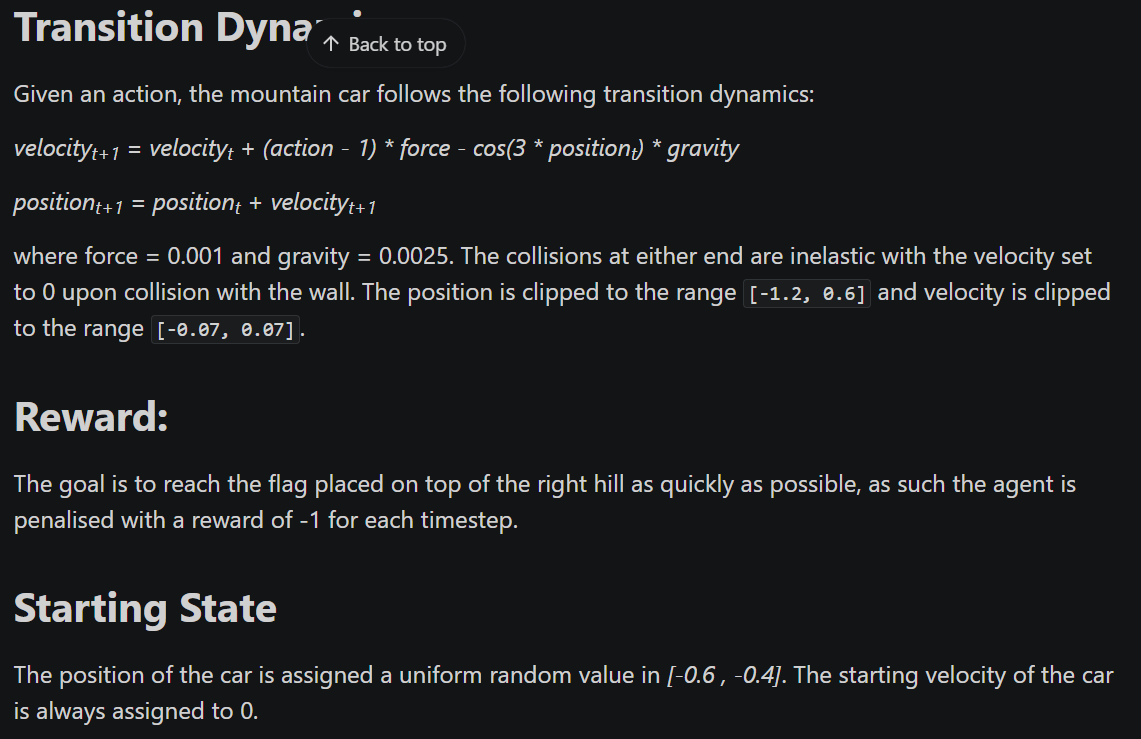
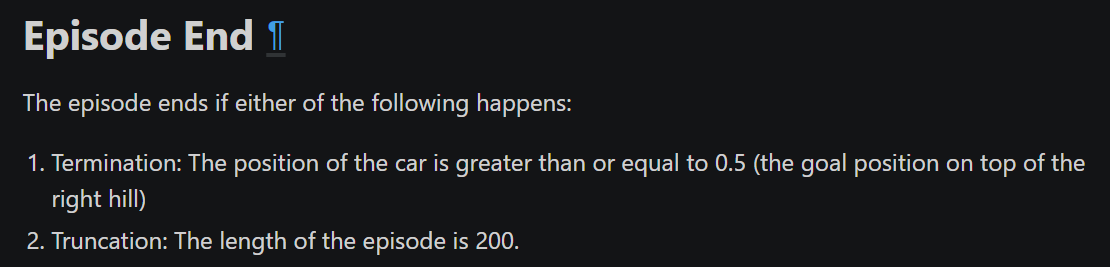


In [172]:
import numpy as np
import matplotlib.pyplot as plt 
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from matplotlib import style
style.use('ggplot')
import random

In [50]:
grid_size=(30,30, 3) #(p,v,a)
iterations=10000
e=1
min_e=.01
gamma=.95
alpha=.1
num_actions=3

In [ ]:
env1= gym.make("MountainCar-v0", render_mode="human")
obs, info=env1.reset()
print(env1.action_space)
print(env1.observation_space)
dis_obs_win_size=(env1.observation_space.high-env1.observation_space.low)/grid_size[0]
#NOTE: observation space is continuous, we'll have to break it into discreate blocks to use Q-learning!!
done=0
r=0
while not done:
    action=env1.action_space.sample()
    observation, reward, terminated, truncated, info = env1.step(action)
    r=r+reward
    done=terminated or truncated

print(f"Episode finished! Total reward: {r}")
env1.close()

Discrete(3)
Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Episode finished! Total reward: -200.0


In [6]:
dis_obs_win_size

array([0.06      , 0.00466667], dtype=float32)

In [136]:
def e_greedy(Q, state, e, A=num_actions):   #e-greedy action selection
    outcomes=np.arange(0,A, dtype=int)
    prob= np.full(outcomes.size, e/A)
    prob[0]=1-e+e/A
    temp=np.argmax(Q[state])
    outcomes[0]=temp
    outcomes[temp]=0
    
    x=random.choices(outcomes, prob, k=1)
    return x[0]   

In [139]:
def eval(P):    #evaluating a policy
    env= gym.make("MountainCar-v0", render_mode="human")
    obs, info=env.reset()
    st=(obs-env.observation_space.low)//dis_obs_win_size
    st=(int(st[0]), int(st[1]))
    done=0
    t=0
    while not done:
        at=P[st]
        obst, rt, terminated, truncated, info = env.step(at)
        st1=(obst-env.observation_space.low)//dis_obs_win_size
        st1=(int(st1[0]), int(st1[1]))
        st=st1
        t=t+1
        
        done=terminated or t%500==0
        
    env.close()
    return t

### Q-Learning with constant learning rate
        epsilon=(.999^episode)

In [161]:
def Q_learn(e, min_e, gamma, alpha, iterations):
    training_period=999
    env=gym.make("MountainCar-v0", render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder="Mountain_car_gym",
        name_prefix="training",
        episode_trigger=lambda x: x % training_period == 0  
    )
    
    Q=np.zeros((grid_size[0], grid_size[1], num_actions))
    N=np.ones((grid_size[0], grid_size[1], num_actions))
    t=0
    e=1
    avg_rewards=[]
    rewards=[]
    epsilon=[]
    episode_len=[]
    last_100=0
    
    for episode in range(iterations):
        obs, info=env.reset()
        st=(obs-env.observation_space.low)//dis_obs_win_size
        st=(int(st[0]), int(st[1]))
        done=0
        sum=0
        step=0
        
        while not done:
            at=e_greedy(Q, st, e)
            obst, rt, terminated, truncated, info = env.step(at)
            sum=sum+rt
            last_100+=rt
            st1=(obst-env.observation_space.low)//dis_obs_win_size
            st1=(int(st1[0]), int(st1[1]))
            
            Q[(st[0], st[1], at)]=Q[(st[0], st[1], at)]+alpha*(rt+gamma*np.max(Q[st1])-Q[(st[0], st[1], at)])
            N[(st[0], st[1], at)]+=1
            
            st=st1
            t=t+1
            step=step+1
            done= terminated or step==500
        
        if(episode%50==0):
            np.save(f"Q_tables_mountain_car/const_alpha/{episode}-qtable.npy", Q)
            avg_rewards.append(last_100/100)
            last_100=0
        e=max(min_e, .999*e)
        rewards.append(sum)
        epsilon.append(e)
        episode_len.append(step)
            
    P=np.zeros((grid_size[0], grid_size[1]), dtype=int)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            P[(i,j)]=np.argmax(Q[(i,j)])
            
    env.close()
    return Q, P, N, rewards, epsilon, episode_len, avg_rewards,

In [162]:
Q_opt, P_opt, N_opt, rewards, epsilon, episode_len, avg_rewards=Q_learn(e, min_e, gamma, alpha, iterations)
np.set_printoptions(precision=3, suppress=True)
print(P_opt)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\wrappers\rendering.py:296: UserWarning: WARN: Overwriting existing videos at d:\Development\Machine_Learning\RL_algorithms\MDPs\Mountain_car_gym folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\wrappers\rendering.py:432: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


[[0 1 2 2 2 1 0 2 0 0 0 0 1 2 1 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 2 1 2 1 1 2 0 0 2 1 2 2 1 1 2 1 1 1 0 0 0 0 0 0 0 0 0]
 [1 0 2 1 2 2 0 1 0 2 1 0 0 1 2 1 2 2 2 2 2 2 2 0 0 0 0 0 0 0]
 [0 0 0 2 1 0 2 0 2 0 0 1 2 2 2 2 2 2 1 1 2 0 2 0 0 0 0 0 0 0]
 [0 0 0 1 2 0 0 0 0 0 2 2 1 2 2 2 1 2 2 2 2 1 2 2 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 2 0 0 1 1 1 2 2 2 2 2 2 2 2 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 2 1 0 2 0 1 1 0 2 2 1 2 1 2 1 0 0 0 0 0]
 [0 0 0 2 0 0 0 0 0 0 1 1 1 2 1 1 1 2 0 2 2 2 2 1 2 2 1 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 0 0]
 [0 0 0 2 0 0 0 0 0 0 0 0 0 2 2 2 0 2 2 2 1 2 2 2 2 2 2 1 0 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 2 2 2 1 2 2 2 2 2 2 2 2 2 0 0]
 [1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 2 2 1 2 2 2 2 2 2 2 2 2 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 2 0 0 2 2 2 2 1 2 2 2 2 1 2 2 2 2 0]
 [2 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 2 0 1 2 2 2 2 2 2 2 2 1 0]
 [0 1 0 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 1 2 2 2 1 2 2 2 2 2 0]
 [0 2 1 1 0 0 0 0 0 0 0 0 1 0 0 0 2 1 0 2 2 0 2 2 2 2 2

In [1]:
steps=eval(P_opt)
steps

NameError: name 'P_opt' is not defined

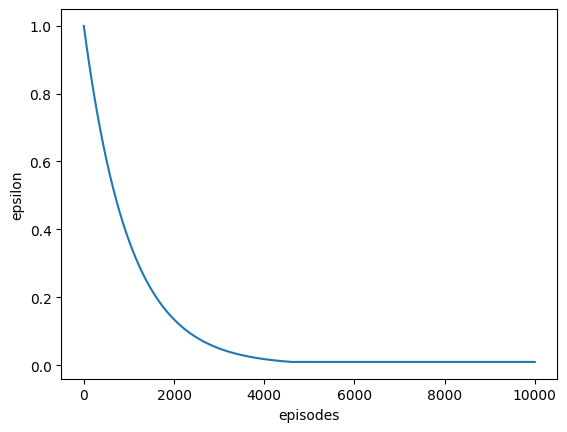

In [164]:
plt.plot(np.arange(iterations), np.array(epsilon))
plt.xlabel("episodes")
plt.ylabel("epsilon")
plt.show()

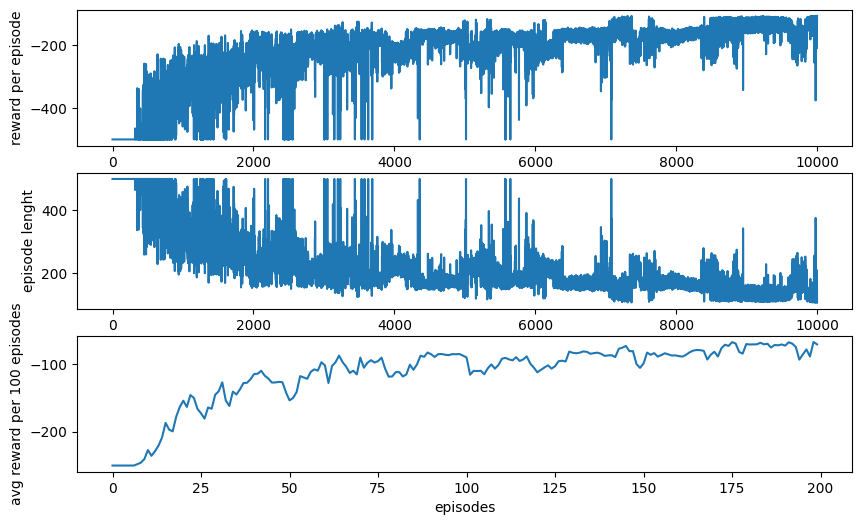

In [165]:
fig, axs=plt.subplots(3, figsize=(10,6))
axs[0].plot(np.arange(iterations), np.array(rewards))
axs[0].set_xlabel("episodes")
axs[0].set_ylabel("reward per episode")
axs[1].plot(np.arange(iterations), np.array(episode_len))
axs[1].set_xlabel("episodes")
axs[1].set_ylabel("episode lenght")
avg_rewards[0]=avg_rewards[1]
axs[2].plot(np.arange(np.array(avg_rewards).shape[0]), np.array(avg_rewards))
axs[2].set_xlabel("episodes")
axs[2].set_ylabel("avg reward per 100 episodes")
plt.show()

In [179]:
def plot_q_table(Q):
    def get_q_color(value, vals):
        if value == max(vals):
            return "green", 1.0
        else:
            return "red", 0.3


    fig = plt.figure(figsize=(12, 9))

    ax1 = fig.add_subplot(311)
    ax2 = fig.add_subplot(312)
    ax3 = fig.add_subplot(313)

    q_table = Q

    for x, x_vals in enumerate(q_table):
        for y, y_vals in enumerate(x_vals):
            ax1.scatter(x, y, c=get_q_color(y_vals[0], y_vals)[0], marker="o", alpha=get_q_color(y_vals[0], y_vals)[1])
            ax2.scatter(x, y, c=get_q_color(y_vals[1], y_vals)[0], marker="o", alpha=get_q_color(y_vals[1], y_vals)[1])
            ax3.scatter(x, y, c=get_q_color(y_vals[2], y_vals)[0], marker="o", alpha=get_q_color(y_vals[2], y_vals)[1])

            ax1.set_ylabel("Action 0")
            ax2.set_ylabel("Action 1")
            ax3.set_ylabel("Action 2")

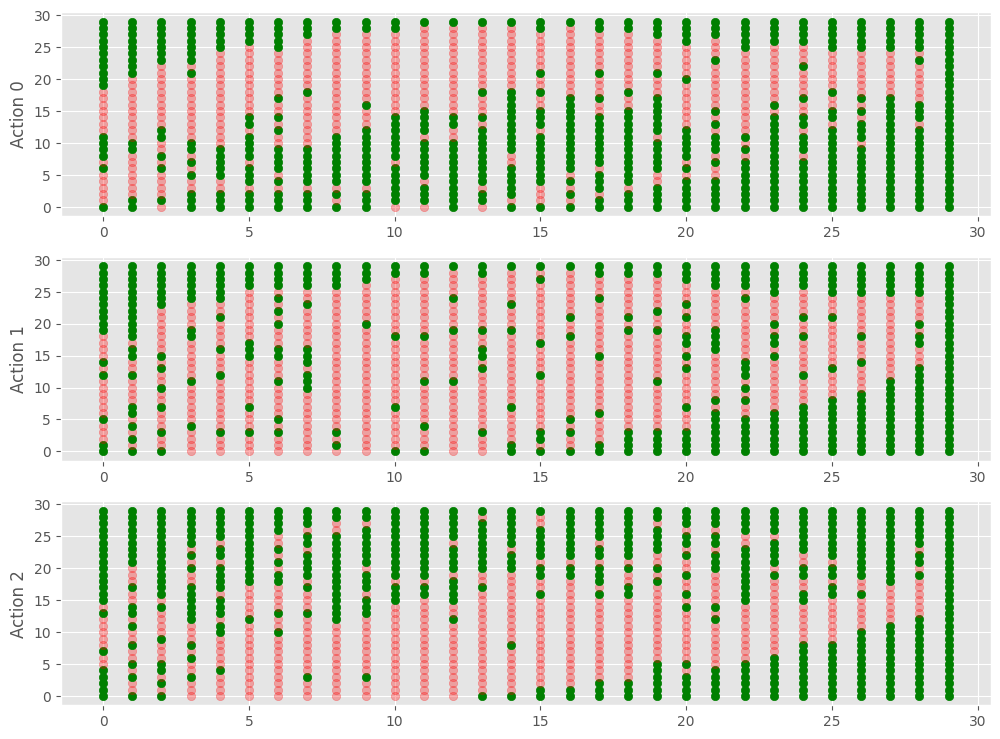

In [175]:
plot_q_table(Q_opt)

### Q-learning with exponentially decaying learning rate
        alpha=(.999^N(s,a))
        epsilon=(.999^episode)

In [168]:
def Q_learn2(e, min_e, gamma, alpha, iterations=5000):
    training_period=999
    env=gym.make("MountainCar-v0", render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder="Mountain_car_gym1",
        name_prefix="training",
        episode_trigger=lambda x: x % training_period == 0  
    )
    env.reset()
    
    Q=np.zeros((grid_size[0], grid_size[1], num_actions))
    N=np.ones((grid_size[0], grid_size[1], num_actions))
    t=0
    avg_rewards=[]
    rewards=[]
    epsilon=[]
    episode_len=[]
    last_100=0
    
    for episode in range(iterations):
        obs, info=env.reset()
        st=(obs-env.observation_space.low)//dis_obs_win_size
        st=(int(st[0]), int(st[1]))
        done=0
        sum=0
        step=0
        
        while not done:
            at=e_greedy(Q, st, e)
            obst, rt, terminated, truncated, info = env.step(at)
            sum=sum+rt
            last_100+=rt
            st1=(obst-env.observation_space.low)//dis_obs_win_size
            st1=(int(st1[0]), int(st1[1]))
            
            Q[(st[0], st[1], at)]=Q[(st[0], st[1], at)]+(N[(st[0], st[1], at)])*(rt+gamma*np.max(Q[st1])-Q[(st[0], st[1], at)])
            N[(st[0], st[1], at)]*=.999
            
            st=st1
            t=t+1
            step=step+1
            done= terminated or step==500
        
        if(episode%50==0):
            np.save(f"Q_tables_mountain_car/decay_alpha/{episode}-qtable.npy", Q)
            avg_rewards.append(last_100/100)
            last_100=0
        e=max(min_e, .999*e)
        rewards.append(sum)
        epsilon.append(e)
        episode_len.append(step)
            
    P=np.zeros((grid_size[0], grid_size[1]), dtype=int)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            P[(i,j)]=np.argmax(Q[(i,j)])
    
    env.close()
    return Q, P, N, rewards, episode_len, avg_rewards

In [169]:
Q_opt1, P_opt1, N_opt1, rewards1, episode_len1, avg_rewards1=Q_learn2(e, min_e, gamma, alpha, iterations)
np.set_printoptions(precision=3, suppress=True)
print(P_opt1)

[[0 0 1 0 1 1 0 2 2 1 1 1 2 1 2 2 2 2 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 2 0 2 0 1 2 2 1 2 0 0 2 1 2 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 2 0 2 2 2 2 1 2 2 1 1 2 2 1 0 0 0 0 0 0 0 0]
 [0 2 0 2 0 0 0 0 2 2 2 2 2 2 1 1 2 2 1 1 2 1 2 1 0 0 0 0 0 0]
 [0 2 0 0 1 1 0 1 2 2 1 1 1 2 2 2 2 0 1 2 2 0 2 1 0 0 0 0 0 0]
 [0 2 1 1 1 1 0 0 0 2 1 2 0 2 1 1 2 0 1 2 2 1 2 1 2 1 0 0 0 0]
 [0 1 1 0 2 1 0 0 0 0 2 0 2 2 2 2 0 2 1 2 0 2 2 1 2 0 0 0 0 0]
 [2 0 0 1 0 1 0 0 0 0 0 0 0 2 2 2 0 2 2 0 2 2 2 2 1 0 1 0 0 0]
 [0 0 2 0 0 0 0 0 0 0 0 0 0 2 2 2 1 2 0 2 0 2 1 1 2 0 2 0 0 0]
 [1 0 2 0 0 1 0 1 0 0 2 0 0 1 2 2 1 1 2 2 2 2 2 2 2 2 2 0 0 0]
 [2 0 1 0 0 0 0 0 0 0 2 1 0 2 2 2 0 2 2 2 2 2 2 2 2 1 2 1 0 0]
 [2 0 0 0 1 0 0 0 0 0 0 0 0 2 0 0 0 2 2 0 0 2 2 2 2 2 2 2 0 0]
 [1 0 2 1 1 1 1 1 0 0 0 0 0 2 0 0 0 2 2 1 1 2 1 2 2 2 2 2 0 0]
 [0 0 1 1 1 0 1 0 0 2 1 0 0 0 0 0 1 1 1 0 0 2 0 2 2 2 2 2 0 0]
 [0 2 1 0 0 1 0 1 0 0 0 0 0 0 1 0 2 1 1 1 0 0 2 2 2 1 2 1 0 0]
 [0 1 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 2 2 2 1 0 1

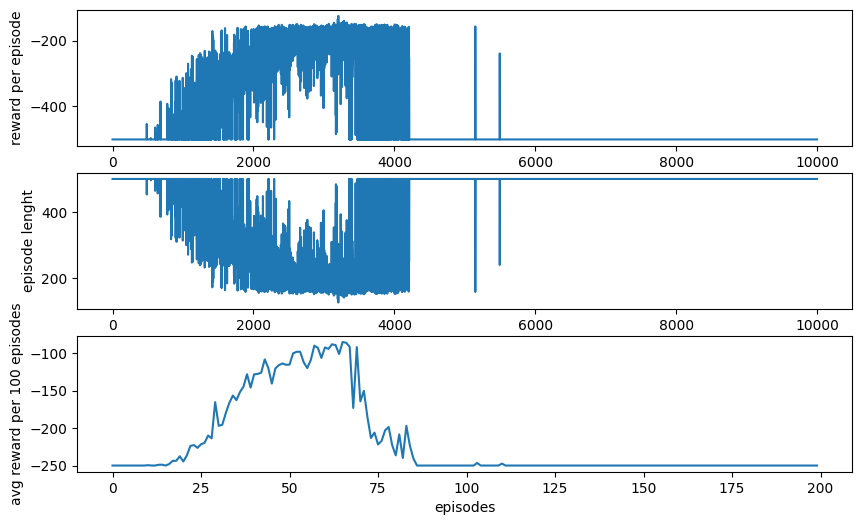

In [170]:
fig, axs1=plt.subplots(3, figsize=(10,6))
axs1[0].plot(np.arange(iterations), np.array(rewards1))
axs1[0].set_xlabel("episodes")
axs1[0].set_ylabel("reward per episode")
axs1[1].plot(np.arange(iterations), np.array(episode_len1))
axs1[1].set_xlabel("episodes")
axs1[1].set_ylabel("episode lenght")
avg_rewards1[0]=avg_rewards1[1]
axs1[2].plot(np.arange(np.array(avg_rewards1).shape[0]), np.array(avg_rewards1))
axs1[2].set_xlabel("episodes")
axs1[2].set_ylabel("avg reward per 100 episodes")
plt.show()

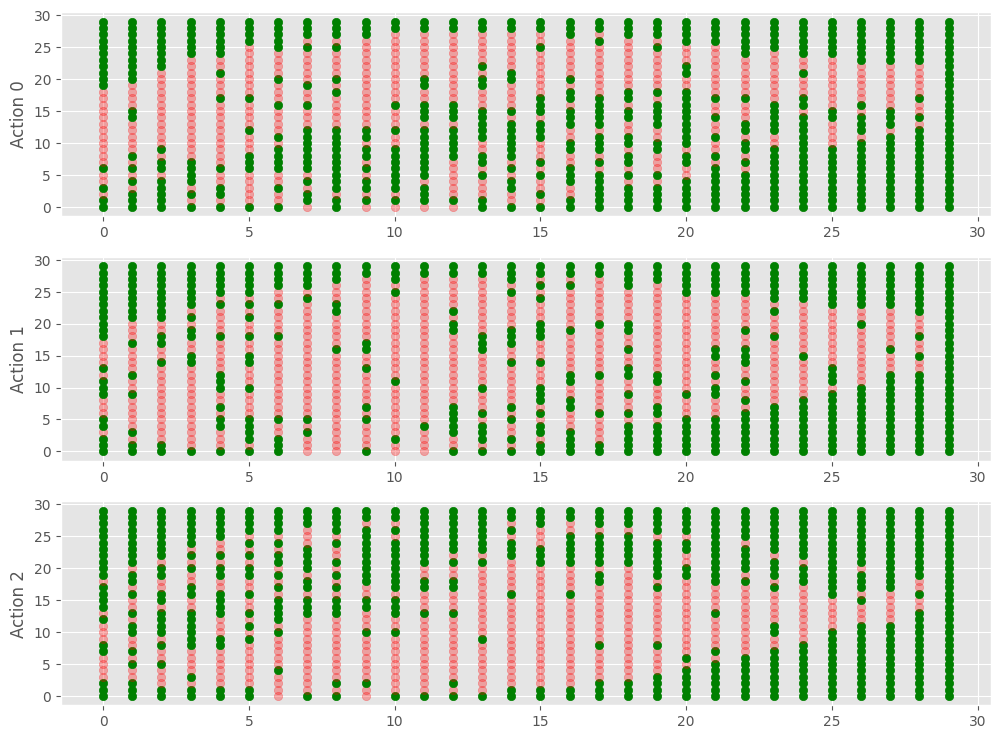

In [176]:
plot_q_table(Q_opt1)

### Observations:
- with alpha constant, the avg rewards obtained increase and then plateau with the number of episodes.
- with the decaying alpha, avg rewards seem to increase till episode 4000 afterwhich a sharp drop is noticed

NOTE: that by episode 4000 epsilon is very small, thus the exploration part is negligible already. This implies that the actions chosen for training henceforth will predominantly be greedy.

Also, in the decayed alpha case:
for start states N(start_state, a) will be somwhere off the order of num_episodes itself, causing negligible updates for Q(start_state, a), thus practically after 4000-5000 episodes Q values of start states do not update atall.

Thus if before the 4000th episode argmax(Q(start_state)) was suboptimal it will remain as is, which happens to be the case here. So from episodes ~4000 to 10000 the agent is stuck in the start state itself.

Infact while evaluating the optimal policy obtained from the decayed alpha training (P_opt1), if we hardcode P_opt1 to just escape the start states, P_opt1 shows similar results as while evaluating the optimal policy obtained from the constant alpha case (P_opt).

Thus, despite the theoretical convergence garunteed by a decaying alpha, we must be very carefull while using it, as it might stall training for crucial states at suboptimal Q-values. On the other hand a small but constant alpha does not garuntee convergence but tends to give good solutions in case of sparse rewards environments like the mountain_climb MDP.


In [171]:
eval(P_opt1)

500